# Compound SV / SHAP mappping

In [1]:
%load_ext autoreload

Failed to read module file 'C:\Users\janela\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\janela\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^

Failed to read module file 'C:\Users\janela\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\janela\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [4]:
import sys
from pathlib import Path

# Resolve workspace root (works whether cwd is notebooks/ or the repo root)
_ws_root = Path.cwd()
if not (_ws_root / "src").exists():
    _ws_root = _ws_root.parent

_servers_dir = _ws_root / "src" / "chemagent" / "servers"

for _p in [str(_ws_root), str(_servers_dir)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

_save_dir = _ws_root / "notebooks" / "debug_outputs"
_save_dir.mkdir(exist_ok=True)

print(f"Workspace root : {_ws_root}")
print(f"Servers dir    : {_servers_dir}")
print(f"Save dir       : {_save_dir}")

Workspace root : c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability
Servers dir    : c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\src\chemagent\servers
Save dir       : c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\notebooks\debug_outputs


# Import libraries

In [5]:
import pandas as pd
from rdkit import Chem
from src.chemagent.explainability.mol_shap_draw import shap_to_atom_weight, get_ecfp_morgan_generator_bit_info, get_atom_wise_weight_map
%autoreload 2

c:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
UsageError: Line magic function `%autoreload` not found.


# Load data

In [4]:
df_shap = pd.read_pickle('df_shap_sample.pkl')
df_shap

,smiles,shap_values
1,O=C(CCC1(c2ccccc2)CCCN(C(=O)Nc2ccc(Cl)cc2)C1)N...,"[0.0, 0.0019224565869103572, -8.21304979763226..."


# Generate MOL, bit info and atom wise shap values

In [5]:
smiles = df_shap["smiles"].iloc[0]
smiles

'O=C(CCC1(c2ccccc2)CCCN(C(=O)Nc2ccc(Cl)cc2)C1)NC1=NNNN1'

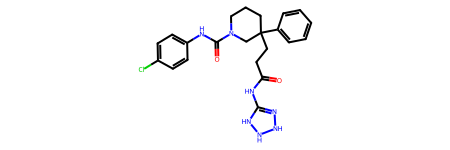

In [6]:
mol = Chem.MolFromSmiles(smiles)
mol 

# Genererate Mol bit info

In [7]:
n_bits = 2048

bit_info = get_ecfp_morgan_generator_bit_info(smiles, n_bits=n_bits, radius=2)
bit_info

{41: ((1, 1),),
 80: ((2, 0), (3, 0)),
 191: ((18, 1),),
 216: ((21, 1),),
 218: ((15, 1),),
 261: ((29, 2),),
 369: ((13, 2),),
 378: ((28, 0),),
 389: ((8, 2),),
 439: ((31, 2),),
 511: ((31, 1),),
 556: ((5, 1),),
 561: ((22, 1),),
 602: ((25, 1),),
 650: ((0, 0), (16, 0)),
 710: ((14, 2),),
 772: ((6, 2), (10, 2)),
 795: ((3, 1),),
 802: ((12, 2),),
 807: ((1, 0), (15, 0)),
 816: ((20, 2), (23, 2)),
 843: ((19, 2), (24, 2)),
 879: ((26, 2),),
 926: ((11, 0), (12, 0), (13, 0), (25, 0)),
 933: ((5, 2),),
 935: ((14, 0),),
 1028: ((12, 1),),
 1060: ((4, 0),),
 1070: ((21, 2),),
 1077: ((18, 2),),
 1088: ((7, 1), (8, 1), (9, 1)),
 1097: ((27, 2),),
 1114: ((29, 0), (30, 0), (31, 0)),
 1152: ((17, 0), (26, 0)),
 1162: ((11, 1),),
 1199: ((7, 2), (9, 2)),
 1219: ((4, 2),),
 1265: ((30, 2),),
 1280: ((27, 1),),
 1371: ((3, 2),),
 1380: ((5, 0), (18, 0), (21, 0), (27, 0)),
 1381: ((15, 2),),
 1382: ((1, 2),),
 1399: ((17, 2),),
 1411: ((11, 2),),
 1471: ((28, 2),),
 1480: ((13, 1),),
 1564

# Get Shap values

In [8]:
shap_values = df_shap.iloc[0]['shap_values']
shap_values

[0.0,
 0.0019224565869103572,
 -8.213049797632265e-05,
 0.0,
 0.00020521651284070687,
 -0.003999535199836828,
 0.0,
 0.0,
 -0.0004587392439680116,
 -0.001579461911458111,
 0.0,
 0.00013843394452123903,
 0.0,
 0.00016400727588916197,
 -0.0004989688510613632,
 -0.00018602624943014234,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0005232506731408648,
 0.0,
 -0.0003699108664295636,
 0.0,
 0.0,
 0.0,
 -5.458560772240162e-06,
 0.0,
 0.0,
 0.0007182493465120388,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0005875408852443798,
 0.0,
 -3.788442350924015e-05,
 0.0,
 0.0,
 -0.0044430455735709985,
 -0.00012342225876636802,
 -0.058674198198905285,
 0.0,
 0.0,
 0.0,
 0.002351666055765236,
 -0.00021906043402850628,
 0.0,
 3.6020628176629546e-05,
 0.0,
 0.0,
 0.0,
 0.0,
 -7.858934812247753e-05,
 0.0,
 0.0,
 -2.4794311029836537e-05,
 5.462102155433968e-05,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00019369659421499818,
 0.0,
 0.0,
 0.0,
 -0.003378554682203685,
 -8.747070001845714e-05,
 -8.544036885723472e-05,
 0.0,
 0.0,
 0.0,
 -0.00014227

# Shap to atom weight

In [9]:
shap_value_to_atom_weight = shap_to_atom_weight(mol=mol, dict_bit_info=bit_info, shapley_values=shap_values)
shap_value_to_atom_weight

[-0.01927166794395302,
 -0.023589381040354084,
 -0.021112157431041393,
 -0.005692540336798162,
 0.0825531490691827,
 0.016377701905816024,
 0.012615033551517942,
 0.0054482717362922635,
 0.005420827679849064,
 0.0054482717362922635,
 0.012615033551517942,
 0.03762676047847111,
 0.055034091306494434,
 0.03828625970276241,
 0.059385020386774554,
 0.039817680052641385,
 0.013612915135843845,
 0.0531530295652776,
 0.048236294511986674,
 0.0406856020870991,
 0.024275571411414808,
 0.025812476187061357,
 0.014939538278184634,
 0.024275571411414808,
 0.0406856020870991,
 0.03651976018856027,
 -0.014210671185153657,
 0.004819711957117642,
 -0.02087332202528785,
 -0.01459687576920983,
 -0.01609313155051006,
 -0.015623058743858003]

# Shap mapping

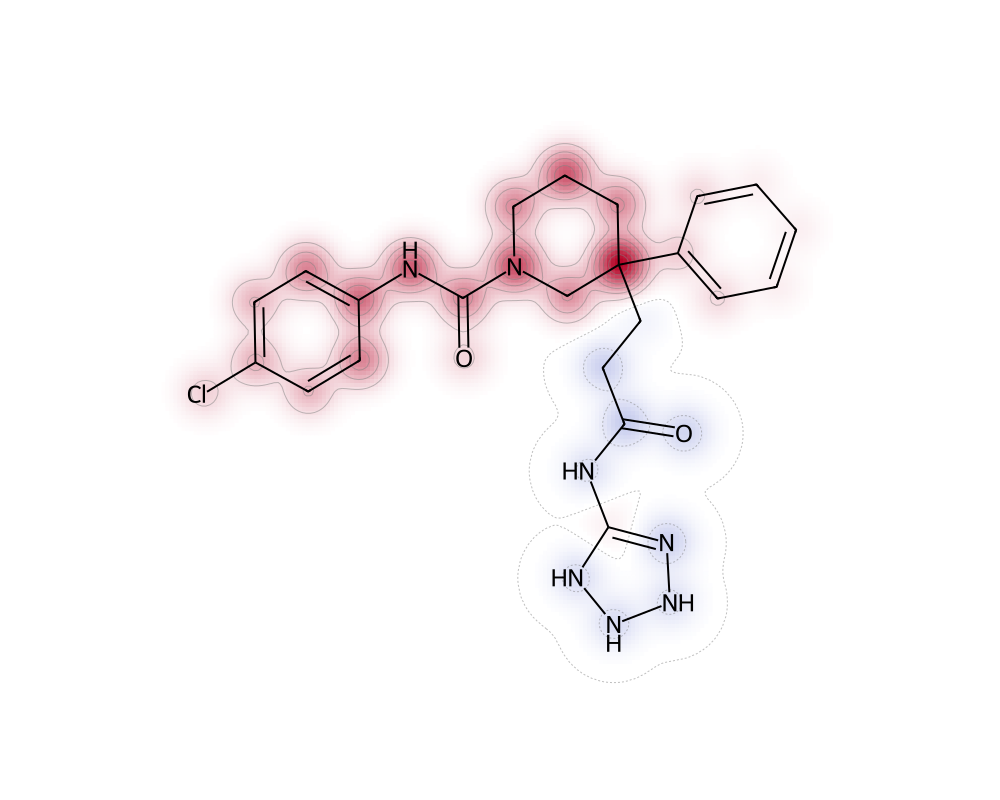

In [10]:
shap_mapping = get_atom_wise_weight_map(mol=mol, weights=shap_value_to_atom_weight, mol_size=(1000, 800))
shap_mapping

In [11]:
shap_mapping.save('shap_mapping.png')

In [6]:
from src.chemagent.servers.chemagent_mcp import explain_with_shap, plot_shap_mol
import os
import numpy as np

In [7]:
import joblib
model_path = os.path.join(_ws_root, './data/logs/session_tiago_20260306_161123_b42e09/models/chembl_O00329_P48736_scaffold_RFC.pkl')

In [8]:
split_file_path = os.path.join(_ws_root, './data/logs/session_tiago_20260306_161123_b42e09/splits/chembl_O00329_P48736_scaffold.pkl')

In [9]:
model = joblib.load(model_path)
split_data = joblib.load(split_file_path)
split_data

{'train_features': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(1021, 2048)),
 'train_labels': array([0, 0, 0, ..., 0, 0, 1], shape=(1021,)),
 'val_features': array([], shape=(0, 2048), dtype=int64),
 'val_labels': array([], dtype=int64),
 'test_features': array([[0, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(256, 2048)),
 'test_labels': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 0, 0, 0, 1,
        1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0,

In [13]:
split_data['test_smiles'][10:11]

<StringArray>
['Cc1cc(-c2ccn3nc(N)c(C(=O)NC4COC4)c3n2)cc2c1C(=O)N(C(C)C1CC1)C2']
Length: 1, dtype: str

In [12]:
split_data['test_labels'][10:11]

array([2])

In [ ]:
split_data_test = np.array(split_data[f"test_features"])[:1]
X_train     = np.array(split_data["train_features"])[:1]
split_data_test

In [7]:
predcition = model.predict(split_data_test)
predcition

array([0])

In [ ]:
# Use SHAP to explain the model
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(split_data_test)
shap_values_predicted_class = shap_values
shap_values_predicted_class

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-7.77078571e-03,  6.86607455e-03,  9.04711162e-04],
        [-9.65621664e-06,  9.65621664e-06,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-1.51333820e-06,  1.51333820e-06,  0.00000000e+00],
        [-1.62122217e-05,  0.00000000e+00,  1.62122217e-05]]],
      shape=(1, 2048, 3))

In [17]:
from src.chemagent.explainability.shap_explainer import SHAPExplainer
explainer    = SHAPExplainer.from_model_path(model_path, background=X_train)
shap_values  = explainer.explain(split_data_test)  # (n_samples, n_features)
expected_val = explainer.expected_value

print("SHAP values:", shap_values)
print("Expected value:", expected_val)

SHAP values: [[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [-7.77078571e-03  6.86607455e-03  9.04711162e-04]
  [-9.65621664e-06  9.65621664e-06  0.00000000e+00]
  ...
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [-1.51333820e-06  1.51333820e-06  0.00000000e+00]
  [-1.62122217e-05  0.00000000e+00  1.62122217e-05]]]
Expected value: 0.742722820763957


In [18]:
shap_values[:, :, 0]

array([[ 0.00000000e+00, -7.77078571e-03, -9.65621664e-06, ...,
         0.00000000e+00, -1.51333820e-06, -1.62122217e-05]],
      shape=(1, 2048))

In [12]:
shap_values_perclass  = explainer.explain_per_predicted_class(split_data_test, predcition)
shap_values_perclass

array([[ 0.00000000e+00, -7.77078571e-03, -9.65621664e-06, ...,
         0.00000000e+00, -1.51333820e-06, -1.62122217e-05]],
      shape=(1, 2048))

In [26]:
mean_abs_per_feature = np.abs(shap_values_perclass).mean(axis=0)
top_bits = np.argsort(mean_abs_per_feature)[::-1][:10].tolist()
top_bits

[358, 1136, 1384, 1620, 790, 708, 674, 213, 690, 1810]

In [27]:
explain_with_shap(model_path=model_path, 
                  split_file_path=split_file_path, 
                  split='test',
                  save_path=os.path.join(_save_dir, 'shap_mapping_test.pkl')
                  )

{'shap_values_path': 'c:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\shap_mapping_test.pkl',
 'n_samples': 226,
 'n_samples_total': 256,
 'n_correct': 226,
 'correct_only': True,
 'n_features': 2048,
 'expected_value': 0.742722820763957,
 'mean_abs_shap': 0.00023822448086587554,
 'top_10_bits': [358, 708, 674, 1136, 1384, 790, 690, 261, 151, 1946],
 'has_smiles': True,
 'next_step': "Call plot_shap_mol('c:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\shap_mapping_test.pkl') to visualise atom-level SHAP heatmaps for individual compounds."}

In [28]:
plot_shap_mol(shap_values_path=os.path.join(_save_dir, 'shap_mapping_test.pkl'))

[{'generated': ['C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260310_145049_f1d912\\plots\\shap_mol_0_label0.png',
   'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260310_145049_f1d912\\plots\\shap_mol_1_label0.png',
   'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260310_145049_f1d912\\plots\\shap_mol_2_label0.png',
   'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260310_145049_f1d912\\plots\\shap_mol_3_label0.png',
   'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260310_145049_f1d912\\plots\\shap_mol_4_label

In [ ]:
_save_dir

WindowsPath('c:/Users/janela/OneDrive - uni-bonn.de/Code/AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability/notebooks/debug_outputs')